In [1]:
!pip install opencv-python matplotlib scikit-learn --quiet

import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
zip_path = "/content/dataset.zip"
extract_path = "/content/dataset/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [6]:
all_files = os.listdir(extract_path)
print("Files:", all_files)

Files: ['10253_idx5_x1001_y651_class0.png', '10253_idx5_x1051_y1501_class0.png', '10253_idx5_x1001_y701_class0.png', '10253_idx5_x1051_y1201_class0.png', '10253_idx5_x1001_y1001_class0.png', '10253_idx5_x1001_y1201_class0.png', 'dataset', '10253_idx5_x1051_y1301_class0.png', '10253_idx5_x1001_y751_class0.png', '10253_idx5_x1051_y1151_class0.png', '10253_idx5_x1051_y1251_class0.png']


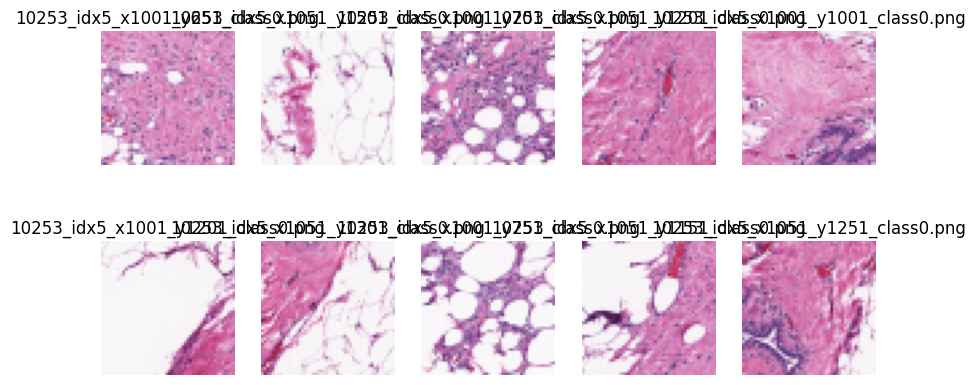

In [10]:
image_files = [f for f in os.listdir(extract_path) if f.endswith(('.png','.jpg','.jpeg'))]

plt.figure(figsize=(10,5))

for i, img_name in enumerate(image_files[:10]):
    img_path = os.path.join(extract_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.show()

In [12]:
processed_images = []

image_paths = [os.path.join(extract_path, img_name) for img_name in image_files]

for img_path in image_paths:
    img = cv2.imread(img_path)

    img = cv2.resize(img, (128,128))   # resize
    img = img / 255.0                  # normalize

    processed_images.append(img)

processed_images = np.array(processed_images)

print("Processed shape:", processed_images.shape)

Processed shape: (10, 128, 128, 3)


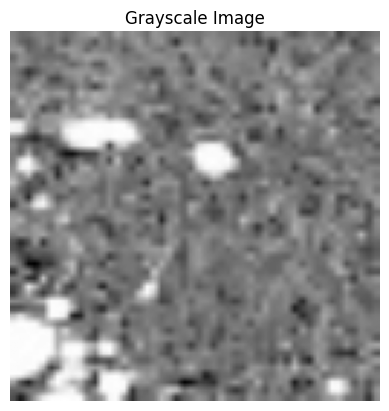

In [13]:
gray = cv2.cvtColor((processed_images[0]*255).astype('uint8'), cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

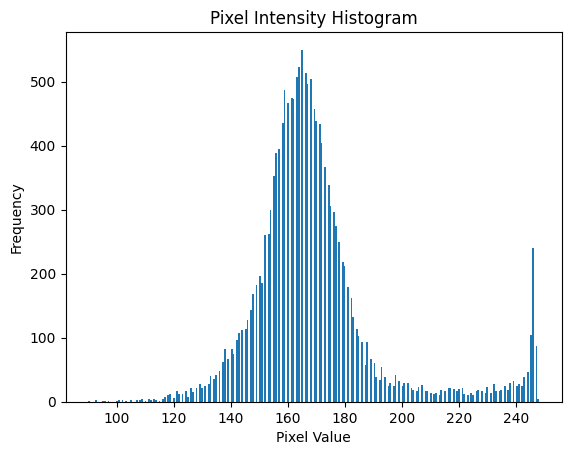

In [14]:
plt.hist(gray.ravel(), bins=256)
plt.title("Pixel Intensity Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

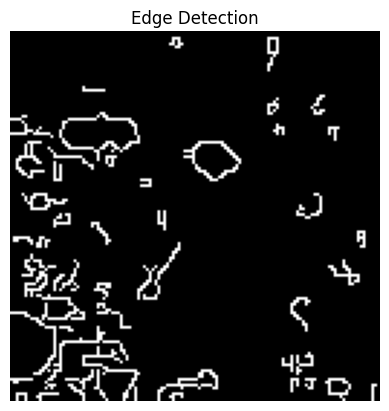

In [15]:
edges = cv2.Canny(gray, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.axis('off')
plt.show()

In [16]:
labels = [i % 2 for i in range(len(processed_images))]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    processed_images, labels, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 8
Test size: 2
